In [65]:
!nvidia-smi

Mon Feb 16 23:26:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [66]:
# Initialize timing log file
LOG_FILE = "timing_log.txt"

def log_timing(label, output, has_kernel=False):
    """Log timing output to file with kernel indicator"""
    kernel_tag = "[GPU KERNEL]" if has_kernel else "[CPU ONLY]"
    with open(LOG_FILE, "a") as f:
        f.write(f"\n{'='*60}\n")
        f.write(f"{kernel_tag} {label}\n")
        f.write(f"{'='*60}\n")
        f.write(output + "\n")

# Clear log file at start of session
with open(LOG_FILE, "w") as f:
    f.write("CUDA Learning - Timing Log\n")
    f.write(f"Generated: {__import__('datetime').datetime.now()}\n")
    
print(f"Timing log initialized: {LOG_FILE}")

Timing log initialized: timing_log.txt


In [67]:
%%writefile hello.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>

#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

__global__ void vecAdd(float* A, float* B, float* C, int N) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i < N) {
        C[i] = A[i] + B[i];
    }
}

int main() {
    const int N = 1500000;

    std::vector<float> h_A(N), h_B(N), h_C(N);

    for (int i = 0; i < N; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float((i + 1) * 10);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, N * sizeof(float)));
    CHECK(cudaMalloc(&d_B, N * sizeof(float)));
    CHECK(cudaMalloc(&d_C, N * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), N * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), N * sizeof(float), cudaMemcpyHostToDevice));

    int blockSize = 512;
    int blocks = (N + blockSize - 1) / blockSize;
    vecAdd<<<blocks, blockSize>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, N * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting hello.cu


In [68]:
!nvcc -arch=sm_70 hello.cu -o hello

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [69]:
import subprocess
result = subprocess.run("nvprof ./hello 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (vecAdd kernel)", output, has_kernel=True)

==14899== NVPROF is profiling process 14899, command: ./hello
==14899== Profiling application: ./hello
==14899== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   66.65%  2.2174ms         2  1.1087ms  1.1057ms  1.1118ms  [CUDA memcpy HtoD]
                   31.17%  1.0369ms         1  1.0369ms  1.0369ms  1.0369ms  [CUDA memcpy DtoH]
                    2.18%  72.576us         1  72.576us  72.576us  72.576us  vecAdd(float*, float*, float*, int)
      API calls:   97.48%  257.13ms         3  85.710ms  65.526us  257.00ms  cudaMalloc
                    1.52%  4.0007ms         3  1.3336ms  1.3090ms  1.3701ms  cudaMemcpy
                    0.65%  1.7193ms       114  15.081us      83ns  879.88us  cuDeviceGetAttribute
                    0.26%  681.77us         3  227.26us  111.05us  285.81us  cudaFree
                    0.05%  143.92us         1  143.92us  143.92us  143.92us  cudaLaunchKernel
                    0.03%  7

CPU Vector Addition

In [70]:
%%writefile main.cpp
#include <iostream>
#include <chrono>
#include <vector>
using namespace std;

int main() {
  
  const int N = 1500000;
  std::vector<int> arr(N);
  for (int i = 0; i < N; i++) {
      arr[i] = i + 1;
  }
  std::vector<int>arr2(N);
  for (int i = 0; i < N; i++) {
    arr2[i] = (i + 1) * 10;
  }
  std::vector<int>arr3(N);
  auto start = std::chrono::high_resolution_clock::now();
  for (int i = 0; i < N; i++) {
    arr3[i] = arr[i] + arr2[i];
    //cout << "arr3[" << i << "] = " << arr3[i] << endl;
  }
  auto end = std::chrono::high_resolution_clock::now();
  auto us = std::chrono::duration_cast<std::chrono::milliseconds>(end - start).count();
  std::cout << "CPU time: " << us << " ms\n";

  return 0;
}

Overwriting main.cpp


In [71]:
!g++ main.cpp -pg -o vector_naive
import subprocess
result = subprocess.run("./vector_naive", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Vector Addition (CPU)", output, has_kernel=False)

CPU time: 62 ms



Naive CUDA Matmul

In [122]:
%%writefile matmul.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>
#include <iostream>
#include <cstdlib>

using namespace std;
#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

__global__ void matmul(float *a, float *b, float *c, int N) {
  int column = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  if (column < N && row < N) {
    float sum = 0;
    for (int i = 0; i < N; i++) {
      sum += a[row * N + i] * b[i * N + column];
    }
    c[row * N + column] = sum;
  }
}

int main(int argc, char *argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    const int size = N * N;

    std::vector<float> h_A(size), h_B(size), h_C(size);

    for (int i = 0; i < size; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float(i + 1);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, size * sizeof(float)));
    CHECK(cudaMalloc(&d_B, size * sizeof(float)));
    CHECK(cudaMalloc(&d_C, size * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), size * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), size * sizeof(float), cudaMemcpyHostToDevice));

    dim3 blockDim(32, 32);
    dim3 gridDim((N + 31) / 32, (N + 31) / 32);
    matmul<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, size * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting matmul.cu


In [73]:
!nvcc -arch=sm_70 matmul.cu -o matmul
import subprocess
result = subprocess.run("nvprof ./matmul 2>&1", shell=True, capture_output=True, text=True)
output = result.stdout + result.stderr
print(output)
log_timing("Matrix Multiplication - Naive (matmul kernel)", output, has_kernel=True)

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
==14964== NVPROF is profiling process 14964, command: ./matmul
==14964== Profiling application: ./matmul
==14964== Profiling result:
            Type  Time(%)      Time     Calls       Avg       Min       Max  Name
 GPU activities:   54.38%  4.7680us         1  4.7680us  4.7680us  4.7680us  matmul(float*, float*, float*, int)
                   23.72%  2.0800us         1  2.0800us  2.0800us  2.0800us  [CUDA memcpy DtoH]
                   21.90%  1.9200us         2     960ns     736ns  1.1840us  [CUDA memcpy HtoD]
      API calls:   99.00%  273.55ms         3  91.184ms  2.0040us  273.55ms  cudaMalloc
                    0.90%  2.4894ms       114  21.836us      91ns  1.3554ms  cuDeviceGetAttribute
                    0.04%  117.62us         1  117.62us  117.62us  117.62us  cudaLaunchKernel
             

CPU Matmul

In [97]:
%%writefile matmul_cpu.cpp
#include <iostream>
#include <chrono>
#include <vector>
#include <cstdlib>

using namespace std;
using namespace std::chrono;

int main(int argc, char* argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    int size = N * N;
    
    std::vector<float> A(size), B(size), C(size);
    for (int i = 0; i < size; i++) {
        A[i] = float(i + 1);
        B[i] = float(i + 1);
    }
    
    auto start = high_resolution_clock::now();
    
    for (int row = 0; row < N; row++) {
        for (int col = 0; col < N; col++) {
            float sum = 0;
            for (int k = 0; k < N; k++) {
                sum += A[row * N + k] * B[k * N + col];
            }
            C[row * N + col] = sum;
        }
    }
    
    auto end = high_resolution_clock::now();
    auto us = duration_cast<microseconds>(end - start).count();
    cout << us << endl;  // Output just the time in microseconds
    
    return 0;
}

Writing matmul_cpu.cpp


In [ ]:
!g++ -O2 matmul_cpu.cpp -o matmul_cpu
print("Compiled CPU matmul")

Shared Memory + Tiling Matmul

In [119]:
%%writefile matmul_tiled.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <vector>
#include <iostream>
#include <cstdlib>

using namespace std;
#define CHECK(call)                                   \
do {                                                  \
    cudaError_t err = call;                           \
    if (err != cudaSuccess) {                         \
        printf("CUDA error %s:%d: %s\n",              \
               __FILE__, __LINE__,                    \
               cudaGetErrorString(err));              \
        exit(1);                                      \
    }                                                 \
} while (0)

#define TILE_SIZE 32

__global__ void matmul(float *a, float *b, float *c, int N) {
  __shared__ float tileA[TILE_SIZE][TILE_SIZE];
  __shared__ float tileB[TILE_SIZE][TILE_SIZE];
  
  int column = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;
  
  float sum = 0;
  
  for (int tileIdx = 0; tileIdx < (N + TILE_SIZE - 1) / TILE_SIZE; tileIdx++) {
    int aCol = tileIdx * TILE_SIZE + threadIdx.x;
    int bRow = tileIdx * TILE_SIZE + threadIdx.y;
    
    // Bounds checking for loading
    tileA[threadIdx.y][threadIdx.x] = (row < N && aCol < N) ? a[row * N + aCol] : 0.0f;
    tileB[threadIdx.y][threadIdx.x] = (bRow < N && column < N) ? b[bRow * N + column] : 0.0f;
    
    __syncthreads();
    
    for (int k = 0; k < TILE_SIZE; k++) {
       sum += tileA[threadIdx.y][k] * tileB[k][threadIdx.x];
    }
    
    __syncthreads();
  }
  
  if (row < N && column < N) {
    c[row * N + column] = sum;
  }
}

int main(int argc, char *argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    const int size = N * N;

    std::vector<float> h_A(size), h_B(size), h_C(size);

    for (int i = 0; i < size; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float(i + 1);
    }

    float *d_A, *d_B, *d_C;
    CHECK(cudaMalloc(&d_A, size * sizeof(float)));
    CHECK(cudaMalloc(&d_B, size * sizeof(float)));
    CHECK(cudaMalloc(&d_C, size * sizeof(float)));

    CHECK(cudaMemcpy(d_A, h_A.data(), size * sizeof(float), cudaMemcpyHostToDevice));
    CHECK(cudaMemcpy(d_B, h_B.data(), size * sizeof(float), cudaMemcpyHostToDevice));

    dim3 blockDim(32, 32);
    dim3 gridDim((N + 31) / 32, (N + 31) / 32);
    matmul<<<gridDim, blockDim>>>(d_A, d_B, d_C, N);

    CHECK(cudaGetLastError());
    CHECK(cudaDeviceSynchronize());

    CHECK(cudaMemcpy(h_C.data(), d_C, size * sizeof(float), cudaMemcpyDeviceToHost));

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Overwriting matmul_tiled.cu


In [102]:
%%writefile matmul_cublas.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <cublas_v2.h>
#include <vector>
#include <cstdlib>

#define CHECK_CUDA(call) \
do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        printf("CUDA error %s:%d: %s\n", __FILE__, __LINE__, cudaGetErrorString(err)); \
        exit(1); \
    } \
} while(0)

#define CHECK_CUBLAS(call) \
do { \
    cublasStatus_t status = call; \
    if (status != CUBLAS_STATUS_SUCCESS) { \
        printf("cuBLAS error %s:%d: %d\n", __FILE__, __LINE__, status); \
        exit(1); \
    } \
} while(0)

int main(int argc, char *argv[]) {
    int N = 16;
    if (argc > 1) {
        N = atoi(argv[1]);
    }
    const int size = N * N;

    std::vector<float> h_A(size), h_B(size), h_C(size);
    for (int i = 0; i < size; i++) {
        h_A[i] = float(i + 1);
        h_B[i] = float(i + 1);
    }

    float *d_A, *d_B, *d_C;
    CHECK_CUDA(cudaMalloc(&d_A, size * sizeof(float)));
    CHECK_CUDA(cudaMalloc(&d_B, size * sizeof(float)));
    CHECK_CUDA(cudaMalloc(&d_C, size * sizeof(float)));

    CHECK_CUDA(cudaMemcpy(d_A, h_A.data(), size * sizeof(float), cudaMemcpyHostToDevice));
    CHECK_CUDA(cudaMemcpy(d_B, h_B.data(), size * sizeof(float), cudaMemcpyHostToDevice));

    // Create cuBLAS handle
    cublasHandle_t handle;
    CHECK_CUBLAS(cublasCreate(&handle));

    // cuBLAS uses column-major, so we compute C = B * A to get row-major result
    // C = alpha * A * B + beta * C
    const float alpha = 1.0f;
    const float beta = 0.0f;
    
    // cublasSgemm: C = alpha * op(A) * op(B) + beta * C
    // For row-major: swap A and B, use transposed dimensions
    CHECK_CUBLAS(cublasSgemm(handle,
                             CUBLAS_OP_N, CUBLAS_OP_N,
                             N, N, N,
                             &alpha,
                             d_B, N,
                             d_A, N,
                             &beta,
                             d_C, N));

    CHECK_CUDA(cudaDeviceSynchronize());

    CHECK_CUDA(cudaMemcpy(h_C.data(), d_C, size * sizeof(float), cudaMemcpyDeviceToHost));

    cublasDestroy(handle);
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Writing matmul_cublas.cu


In [120]:
!nvcc -arch=sm_70 matmul.cu -o matmul
!nvcc -arch=sm_70 matmul_tiled.cu -o matmul-tiled
!nvcc -arch=sm_70 matmul_cublas.cu -lcublas -o matmul-cublas
!g++ -O2 matmul_cpu.cpp -o matmul_cpu
print("Compiled: naive GPU, tiled GPU, cuBLAS, CPU")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compiled: naive GPU, tiled GPU, cuBLAS, CPU


## Naive vs Tiled Matmul Benchmark

In [123]:
import subprocess
import re
import matplotlib.pyplot as plt

def parse_time_value(time_str):
    """Convert time string like '4.51ms' or '327.08us' to microseconds"""
    match = re.match(r'([\d.]+)(ms|us|ns|s)', time_str.strip())
    if not match:
        return None
    val = float(match.group(1))
    unit = match.group(2)
    if unit == 's':
        return val * 1_000_000
    elif unit == 'ms':
        return val * 1_000
    elif unit == 'us':
        return val
    elif unit == 'ns':
        return val / 1_000
    return None

def parse_kernel_time(nvprof_output, kernel_pattern='matmul'):
    """Extract kernel execution time from nvprof output (in microseconds)"""
    for line in nvprof_output.split('\n'):
        # Match custom kernels or cuBLAS sgemm kernels
        if kernel_pattern in line.lower() or 'sgemm' in line.lower() or 'gemm' in line.lower():
            if 'GPU activities' in line or '%' in line:
                parts = line.split()
                for part in parts:
                    if '%' in part:
                        continue
                    if re.match(r'[\d.]+(ms|us|ns|s)$', part):
                        return parse_time_value(part)
    return None

def run_gpu_benchmark(executable, N):
    """Run nvprof on executable with matrix size N, return kernel time in us"""
    cmd = f"nvprof ./{executable} {N} 2>&1"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    output = result.stdout + result.stderr
    return parse_kernel_time(output), output

def run_cpu_benchmark(N):
    """Run CPU matmul with matrix size N, return time in us"""
    cmd = f"./matmul_cpu {N}"
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    try:
        return float(result.stdout.strip())
    except:
        return None

# Matrix sizes to test
sizes = [2 ** (x+1) for x in range (4, 11)]

cpu_times = []
naive_times = []
tiled_times = []
cublas_times = []

print("Running benchmarks (CPU + GPU + cuBLAS)...")
print("-" * 85)
print(f"{'Size':<10} {'CPU':<12} {'Naive GPU':<12} {'Tiled GPU':<12} {'cuBLAS':<12} {'vs cuBLAS':<12}")
print("-" * 85)

for N in sizes:
    cpu_time = run_cpu_benchmark(N)
    naive_time, _ = run_gpu_benchmark("matmul", N)
    tiled_time, _ = run_gpu_benchmark("matmul-tiled", N)
    cublas_time, _ = run_gpu_benchmark("matmul-cublas", N)
    
    cpu_times.append(cpu_time)
    naive_times.append(naive_time)
    tiled_times.append(tiled_time)
    cublas_times.append(cublas_time)
    
    def fmt(t):
        return f"{t:.1f}us" if t else "FAIL"
    
    # Show how many x slower tiled is compared to cuBLAS
    if tiled_time and cublas_time:
        ratio = tiled_time / cublas_time
        ratio_str = f"{ratio:.1f}x slower"
    else:
        ratio_str = "N/A"
    
    print(f"{N}x{N:<7} {fmt(cpu_time):<12} {fmt(naive_time):<12} {fmt(tiled_time):<12} {fmt(cublas_time):<12} {ratio_str:<12}")

# Log results to file
with open(LOG_FILE, "a") as f:
    f.write(f"\n{'='*85}\n")
    f.write("[BENCHMARK] CPU vs GPU vs cuBLAS Matmul Comparison\n")
    f.write(f"{'='*85}\n")
    f.write(f"{'Size':<10} {'CPU (us)':<12} {'Naive':<12} {'Tiled':<12} {'cuBLAS':<12} {'Tiled/cuBLAS':<12}\n")
    f.write("-" * 85 + "\n")
    for i, N in enumerate(sizes):
        if all([cpu_times[i], naive_times[i], tiled_times[i], cublas_times[i]]):
            ratio = tiled_times[i] / cublas_times[i]
            f.write(f"{N}x{N:<7} {cpu_times[i]:<12.1f} {naive_times[i]:<12.1f} {tiled_times[i]:<12.1f} {cublas_times[i]:<12.1f} {ratio:<12.1f}x\n")

print("\nResults logged to", LOG_FILE)

Running benchmarks (CPU + GPU + cuBLAS)...
-------------------------------------------------------------------------------------
Size       CPU          Naive GPU    Tiled GPU    cuBLAS       vs cuBLAS   
-------------------------------------------------------------------------------------
32x32      28.0us       5.9us        5.9us        6.2us        1.0x slower 
64x64      243.0us      4.9us        7.1us        7.7us        0.9x slower 
128x128     2299.0us     18.5us       13.6us       8.4us        1.6x slower 
256x256     20005.0us    119.6us      55.4us       20.4us       2.7x slower 
512x512     312217.0us   552.2us      368.0us      58.7us       6.3x slower 
1024x1024    3165312.0us  8142.6us     3269.8us     441.3us      7.4x slower 
2048x2048    75992135.0us 57752.0us    34994.0us    3629.3us     9.6x slower 

Results logged to timing_log.txt


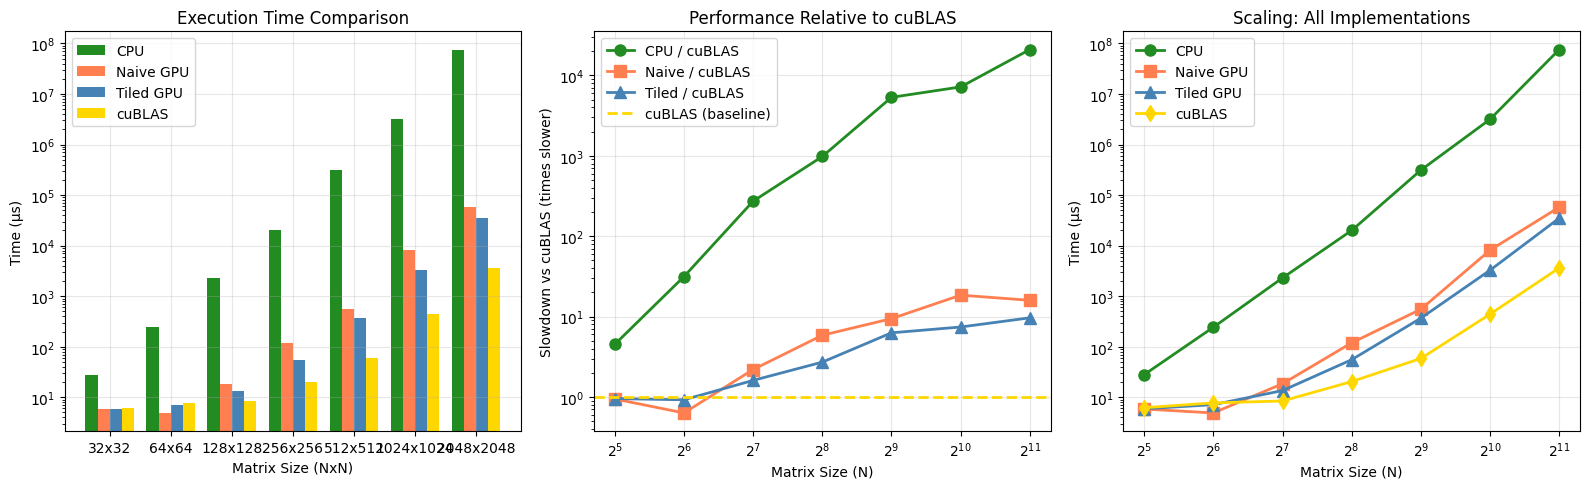

Graph saved to matmul_benchmark.png


In [124]:
# Filter out None values for plotting
valid_idx = [i for i in range(len(sizes)) if all([cpu_times[i], naive_times[i], tiled_times[i], cublas_times[i]])]
v_sizes = [sizes[i] for i in valid_idx]
v_cpu = [cpu_times[i] for i in valid_idx]
v_naive = [naive_times[i] for i in valid_idx]
v_tiled = [tiled_times[i] for i in valid_idx]
v_cublas = [cublas_times[i] for i in valid_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: All execution times (log scale bar chart)
ax1 = axes[0]
x = range(len(v_sizes))
width = 0.2
ax1.bar([i - 1.5*width for i in x], v_cpu, width, label='CPU', color='forestgreen')
ax1.bar([i - 0.5*width for i in x], v_naive, width, label='Naive GPU', color='coral')
ax1.bar([i + 0.5*width for i in x], v_tiled, width, label='Tiled GPU', color='steelblue')
ax1.bar([i + 1.5*width for i in x], v_cublas, width, label='cuBLAS', color='gold')
ax1.set_xlabel('Matrix Size (NxN)')
ax1.set_ylabel('Time (μs)')
ax1.set_title('Execution Time Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{s}x{s}' for s in v_sizes])
ax1.set_yscale('log')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Speedup relative to cuBLAS (how many x slower)
ax2 = axes[1]
naive_vs_cublas = [n/c for n, c in zip(v_naive, v_cublas)]
tiled_vs_cublas = [t/c for t, c in zip(v_tiled, v_cublas)]
cpu_vs_cublas = [cp/c for cp, c in zip(v_cpu, v_cublas)]

ax2.plot(v_sizes, cpu_vs_cublas, 'o-', label='CPU / cuBLAS', color='forestgreen', linewidth=2, markersize=8)
ax2.plot(v_sizes, naive_vs_cublas, 's-', label='Naive / cuBLAS', color='coral', linewidth=2, markersize=8)
ax2.plot(v_sizes, tiled_vs_cublas, '^-', label='Tiled / cuBLAS', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=1, color='gold', linestyle='--', linewidth=2, label='cuBLAS (baseline)')
ax2.set_xlabel('Matrix Size (N)')
ax2.set_ylabel('Slowdown vs cuBLAS (times slower)')
ax2.set_title('Performance Relative to cuBLAS')
ax2.set_xscale('log', base=2)
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Scaling comparison (line plot)
ax3 = axes[2]
ax3.plot(v_sizes, v_cpu, 'o-', label='CPU', color='forestgreen', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_naive, 's-', label='Naive GPU', color='coral', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_tiled, '^-', label='Tiled GPU', color='steelblue', linewidth=2, markersize=8)
ax3.plot(v_sizes, v_cublas, 'd-', label='cuBLAS', color='gold', linewidth=2, markersize=8)
ax3.set_xlabel('Matrix Size (N)')
ax3.set_ylabel('Time (μs)')
ax3.set_title('Scaling: All Implementations')
ax3.set_xscale('log', base=2)
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_benchmark.png', dpi=150)
plt.show()

print("Graph saved to matmul_benchmark.png")